In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [2]:
# doc csv 
df_raw = pd.read_csv('./data/healthcare-dataset-stroke-data.csv')
df_raw.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB


In [4]:
df_raw.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [5]:
# Xem chi tiet so lieu cua nguoi bi dot quy
df_raw[df_raw['stroke']==1].describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,249.000000,249.000000,249.000000,249.000000,249.000000,209.000000,249.0
mean,37115.068273,67.728193,0.265060,0.188755,132.544739,30.471292,1.0
std,21993.344872,12.727419,0.442254,0.392102,61.921056,6.329452,0.0
min,210.000000,1.320000,0.000000,0.000000,56.110000,16.900000,1.0
25%,17013.000000,59.000000,0.000000,0.000000,79.790000,26.400000,1.0
50%,36706.000000,71.000000,0.000000,0.000000,105.220000,29.700000,1.0
75%,56669.000000,78.000000,1.000000,0.000000,196.710000,33.700000,1.0
max,72918.000000,82.000000,1.000000,1.000000,271.740000,56.600000,1.0


In [6]:
# check xem co du lieu nao null khong
df_raw.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [7]:
# fill so lieu bmi bang mean 
df_raw['bmi']= df_raw['bmi'].fillna(df_raw['bmi'].mean())

In [8]:
# bo cac dong bi duplicate
df_raw.drop_duplicates(inplace=True)
# reset lai index
df_raw.reset_index(inplace=True)

In [9]:
df_raw

,index,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0
5106,5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


In [10]:
df_raw.drop(labels='index',axis=1,inplace=True) # drop 1 dong index du

In [11]:
# xem su tuong quan 
corr= df_raw.corr(numeric_only=True)
corr

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
id,1.000000,0.003538,0.003550,-0.001296,0.001092,0.002999,0.006388
age,0.003538,1.000000,0.276398,0.263796,0.238171,0.325942,0.245257
hypertension,0.003550,0.276398,1.000000,0.108306,0.174474,0.160189,0.127904
heart_disease,-0.001296,0.263796,0.108306,1.000000,0.161857,0.038899,0.134914
avg_glucose_level,0.001092,0.238171,0.174474,0.161857,1.000000,0.168751,0.131945
bmi,0.002999,0.325942,0.160189,0.038899,0.168751,1.000000,0.038947
stroke,0.006388,0.245257,0.127904,0.134914,0.131945,0.038947,1.000000


In [12]:
# xem su tuong quan doi voi dot quy
corr_stroke = corr['stroke'].sort_values(ascending=False)
corr_stroke

stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
bmi                  0.038947
id                   0.006388
Name: stroke, dtype: float64

In [13]:
# drop cot id vi khong quan trong
df_raw.drop(columns='id',inplace=True)

### EDA

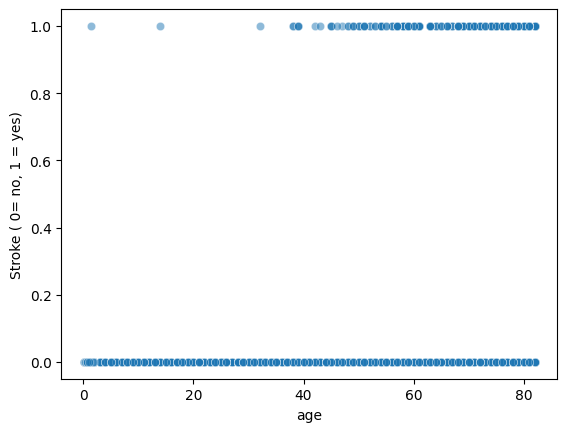

Nguoi lon tuoi co nguy co bi dot quy cao


In [14]:
# Xem nguy co bi dot quy theo tuoi
ax=sns.scatterplot(data=df_raw,x='age',y='stroke',alpha=0.5)
ax.set_ylabel('Stroke ( 0= no, 1 = yes)')
plt.show()
print('Nguoi lon tuoi co nguy co bi dot quy cao')

In [15]:
tuoi_tb=df_raw[df_raw['stroke'] == 1]['age'].mean()
print(f'Tuoi trung binh nguoi bi dot quy: {tuoi_tb:.2f}')

Tuoi trung binh nguoi bi dot quy: 67.73


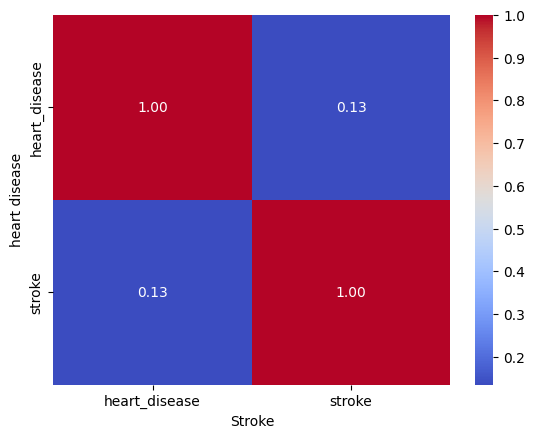

Khong phai benh nhan nao bi benh tim cung co nguy co dot quy


In [16]:
# xem su tuong quan giua benh tim va dot quy
df_heart_stroke = df_raw[['heart_disease', 'stroke']].corr()
sns.heatmap(data=df_heart_stroke, annot=True, cmap='coolwarm', fmt='.2f')
plt.xlabel('Stroke')
plt.ylabel('heart disease')
plt.show()
print('Khong phai benh nhan nao bi benh tim cung co nguy co dot quy')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_31552\3966990632.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x='stroke', y='avg_glucose_level', palette='coolwarm')


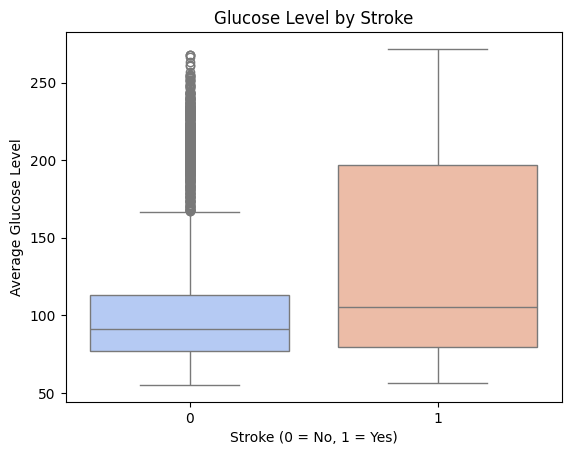

In [17]:
# xem ti le duong huyet giua nhom nguoi dot quy va khong dot quy
sns.boxplot(data=df_raw, x='stroke', y='avg_glucose_level', palette='coolwarm')
plt.title('Glucose Level by Stroke')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Average Glucose Level')
plt.show()
 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_31552\1683769864.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x='stroke', y='bmi', palette='coolwarm')


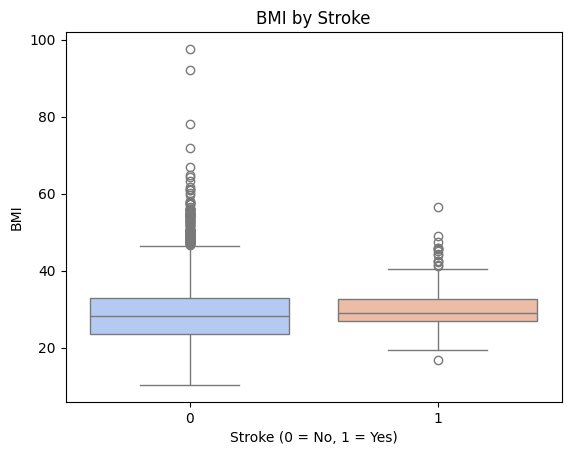

In [18]:
sns.boxplot(data=df_raw, x='stroke', y='bmi', palette='coolwarm')
plt.title('BMI by Stroke')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('BMI')
plt.show()

### Outlier

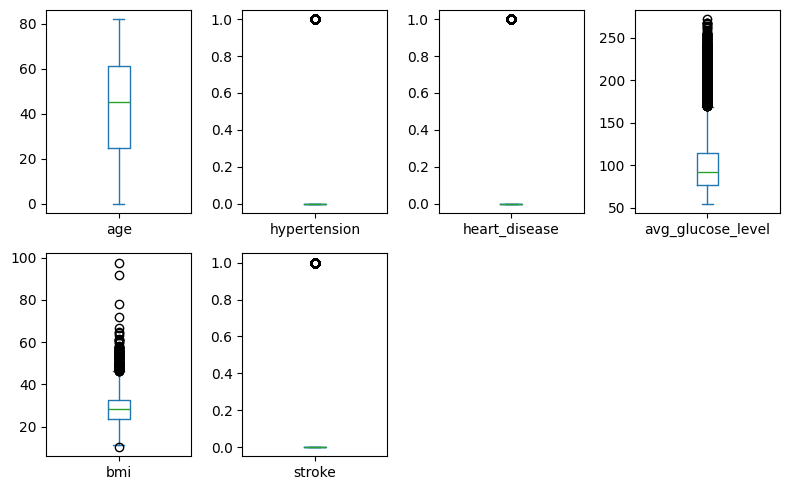

In [19]:
# Kiem tra outlier cua tung cot du lieu qua box plot
df_raw.select_dtypes(include='number').plot(kind='box',subplots=True,layout=(2,4),figsize=(8,5))
plt.tight_layout()
plt.show()

In [20]:
# giu lai du lieu co bmi duoi 80
df_raw=df_raw[df_raw['bmi']<80]

In [21]:
# tao 1 bang moi chua thong tin quan trong
df = df_raw.drop(columns =['ever_married','Residence_type','work_type'])

In [22]:
# doi cot smoking status thanh dang nhi phan (one-hot encoding)
df=pd.get_dummies(df,columns=['smoking_status'],dtype=int)

In [23]:
# Co nhieu do tuoi khac nhau nen phai gop thanh nhom
df['age'].describe()

count    5108.000000
mean       43.232772
std        22.613977
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

In [24]:
# chia nhom tuoi
bins= [0,17,30,50,90]
labels= ['0-17','18-30','31-50','51-90']
df['age']=pd.cut(df['age'],bins=bins, labels=labels)
df.head()

,gender,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,Male,51-90,0,1,228.69,36.600000,1,0,1,0,0
1,Female,51-90,0,0,202.21,28.893237,1,0,0,1,0
2,Male,51-90,0,1,105.92,32.500000,1,0,0,1,0
3,Female,31-50,0,0,171.23,34.400000,1,0,0,0,1
4,Female,51-90,1,0,174.12,24.000000,1,0,0,1,0


In [25]:
# Encode gioi tinh: Male = 1, Female = 0
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['gender']=le.fit_transform(df['gender'])

In [26]:
df.dtypes

gender                               int64
age                               category
hypertension                         int64
heart_disease                        int64
avg_glucose_level                  float64
bmi                                float64
stroke                               int64
smoking_status_Unknown               int64
smoking_status_formerly smoked       int64
smoking_status_never smoked          int64
smoking_status_smokes                int64
dtype: object

In [27]:
# doi type du lieu cot age, phan loai tuoi theo so
df['age']=le.fit_transform(df['age'])
df.dtypes

gender                              int64
age                                 int64
hypertension                        int64
heart_disease                       int64
avg_glucose_level                 float64
bmi                               float64
stroke                              int64
smoking_status_Unknown              int64
smoking_status_formerly smoked      int64
smoking_status_never smoked         int64
smoking_status_smokes               int64
dtype: object

C:\Users\ASUS\AppData\Local\Temp\ipykernel_31552\3841046643.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='stroke', palette='Set2')


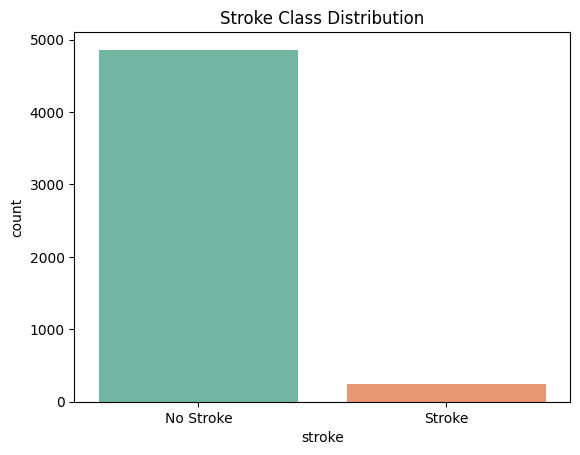

Khong co su can bang giua du lieu. Co the dan de sai sot trong machine learning


In [28]:
# Xem do chenh lech du lieu
ax = sns.countplot(data=df, x='stroke', palette='Set2')
plt.xticks([0, 1], ['No Stroke', 'Stroke'])
plt.title('Stroke Class Distribution')
plt.show()
print('Khong co su can bang giua du lieu. Co the dan de sai sot trong machine learning')


### Model

In [29]:
# Chia train/test truoc, stratify=y de giu ti le stroke o ca hai tap
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score, classification_report,
                             recall_score)
X = df.drop(columns='stroke')
y = df['stroke']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Chi ap dung SMOTE tren tap train, tap test giu nguyen
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Train truoc SMOTE:', y_train.value_counts().to_dict())
print('Train sau SMOTE:  ', y_train_bal.value_counts().to_dict())
print('Test (goc):       ', y_test.value_counts().to_dict())

Train truoc SMOTE: {0: 3887, 1: 199}
Train sau SMOTE:   {0: 3887, 1: 3887}
Test (goc):        {0: 972, 1: 50}


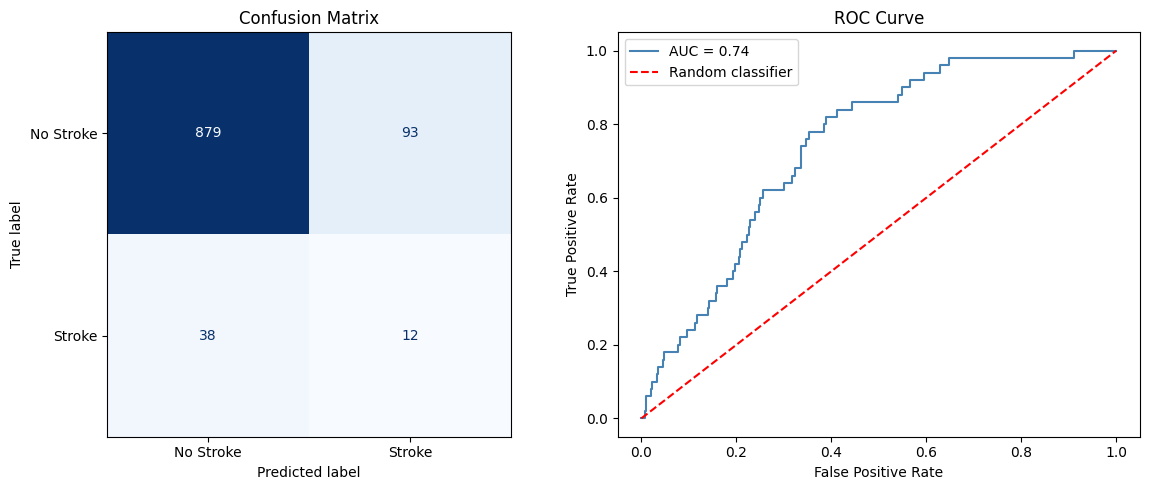

Recall (Stroke): 0.240
ROC-AUC:         0.742
              precision    recall  f1-score   support

   No Stroke       0.96      0.90      0.93       972
      Stroke       0.11      0.24      0.15        50

    accuracy                           0.87      1022
   macro avg       0.54      0.57      0.54      1022
weighted avg       0.92      0.87      0.89      1022



In [30]:
# Logistic Regression: train tren du lieu da SMOTE, danh gia tren test goc
model = LogisticRegression(max_iter=1000)
model.fit(X_train_bal, y_train_bal)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability for class 1 (stroke)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Ve confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Stroke", "Stroke"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# Ve do thi ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color="steelblue", label=f"AUC = {auc:.2f}")
axes[1].plot([0, 1], [0, 1], "r--", label="Random classifier")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Recall (Stroke): {recall_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:         {auc:.3f}")
print(classification_report(y_test, y_pred, target_names=["No Stroke", "Stroke"]))

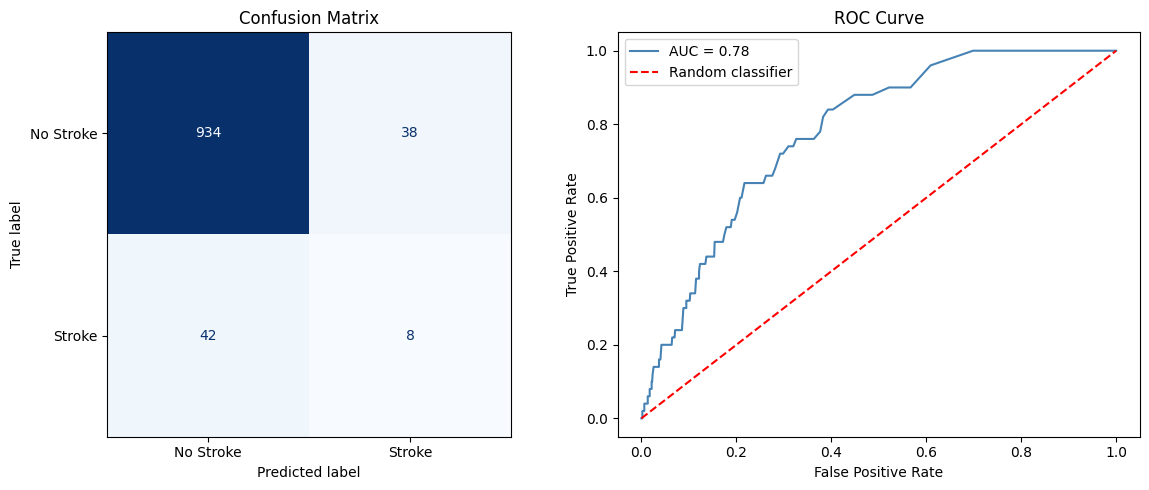

Recall (Stroke): 0.160
ROC-AUC:         0.780
              precision    recall  f1-score   support

   No Stroke       0.96      0.96      0.96       972
      Stroke       0.17      0.16      0.17        50

    accuracy                           0.92      1022
   macro avg       0.57      0.56      0.56      1022
weighted avg       0.92      0.92      0.92      1022



In [31]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest: train tren du lieu da SMOTE, danh gia tren test goc
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_bal, y_train_bal)

y_pred = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Ve confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Stroke", "Stroke"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# Ve do thi ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc = roc_auc_score(y_test, y_prob_rf)
axes[1].plot(fpr, tpr, color="steelblue", label=f"AUC = {auc:.2f}")
axes[1].plot([0, 1], [0, 1], "r--", label="Random classifier")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Recall (Stroke): {recall_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:         {auc:.3f}")
print(classification_report(y_test, y_pred, target_names=["No Stroke", "Stroke"]))

## Conclusion

#### Mất cân bằng dữ liệu
Theo dữ liệu ban đầu, chỉ có 249 bệnh nhân bị đột quỵ (4.87%) — dữ liệu mất cân bằng nghiêm trọng. Quy trình đánh giá: chia train/test trước (80/20, `stratify=y` để giữ tỉ lệ đột quỵ ở cả hai tập), sau đó chỉ áp dụng SMOTE trên tập train (3,887 / 3,887 mẫu mỗi lớp). Tập test (972 không đột quỵ / 50 đột quỵ) giữ nguyên phân phối gốc, chưa qua SMOTE.

#### EDA
Dựa vào phân tích dữ liệu, các yếu tố tương quan với đột quỵ như sau:

| Yếu tố            | Tương quan |
|-------------------|------------|
| Tuổi              | 0.245      |
| Bệnh tim          | 0.135      |
| Đường huyết       | 0.132      |
| Huyết áp cao      | 0.128      |
| BMI               | 0.039      |

Bệnh nhân đột quỵ có độ tuổi trung bình là **67.7 tuổi**, cao hơn nhiều so với trung bình toàn bộ dữ liệu (43.2 tuổi) — cho thấy tuổi tác là yếu tố nguy cơ quan trọng nhất.

#### So sánh mô hình (đánh giá trên tập test gốc)
Với dữ liệu mất cân bằng, accuracy dễ gây hiểu nhầm nên ta xem Recall của lớp Stroke và ROC-AUC.

| Chỉ số               | Logistic Regression | Random Forest |
|----------------------|---------------------|---------------|
| Recall (Đột quỵ)     | **24%**             | 16%           |
| ROC-AUC              | 0.742               | **0.780**     |
| Precision (Đột quỵ)  | 11%                 | 17%           |

#### Kết luận
Các con số trước đây (accuracy 96%, recall 95%) bị thổi phồng do SMOTE được áp dụng trước khi chia tập, khiến mẫu tổng hợp rò rỉ sang tập test. Khi đánh giá đúng cách, cả hai mô hình đều còn yếu trong việc phát hiện đột quỵ: Random Forest có ROC-AUC cao hơn (0.78 so với 0.74) nhưng recall chỉ 16%, Logistic Regression recall 24% nhưng vẫn bỏ sót phần lớn ca đột quỵ. Cần cải thiện thêm (điều chỉnh ngưỡng quyết định, class_weight, thêm đặc trưng, cross-validation) trước khi dùng trong thực tế y tế.


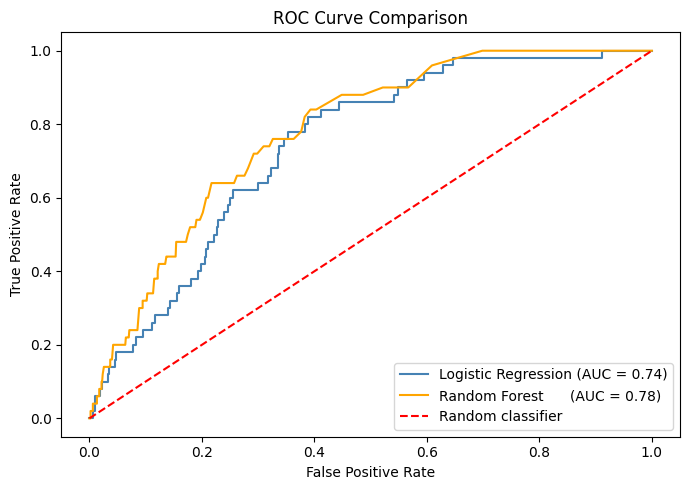

In [32]:
# Get probabilities from both models
y_prob_lr = model.predict_proba(X_test)[:, 1]   # Logistic Regression
y_prob_rf = rf.predict_proba(X_test)[:, 1]      # Random Forest

# Compute ROC for each
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Plot both on the same chart
plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})", color="steelblue")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest      (AUC = {auc_rf:.2f})", color="orange")
plt.plot([0, 1], [0, 1], "r--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()
